In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
data=pd.read_csv('/kaggle/input/titanic/train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


2. Replace the values in 'Embarked' column and make separate values for each of the following values it contains in that column Note : We are converting strings into int to prevent further errors that would occur in the followig steps

In [3]:
data.Embarked.unique()
data['Embarked_s']=data['Embarked'].replace('Q',0).replace('C',0).replace('S',1)
data['Embarked_c']=data['Embarked'].replace('S',0).replace('Q',0).replace('C',1)
data['Embarked_q']=data['Embarked'].replace('C',0).replace('S',0).replace('Q',1)

In [4]:
#data.Sex= data.Sex.map( {'M': 1, 'F': 0, 'O': 3} )
data['Sex'].replace( 'female', 0, inplace=True )
data['Sex'].replace( 'male', 1, inplace=True )
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_s,Embarked_c,Embarked_q
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,1.0,0.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,0.0,1.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1.0,0.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,1.0,0.0,0.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S,1.0,0.0,0.0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S,1.0,0.0,0.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,S,1.0,0.0,0.0
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C,0.0,1.0,0.0


If you want to remove 0 value in 'Embarked' column then simply run the code given below and get the required data .

In [5]:
#data=data[data.Embarked!=0]
#data=data[data[('Embarked')].map(data['Embarked'].value_counts())>0]*
#data

In [6]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Embarked_s       2
Embarked_c       2
Embarked_q       2
dtype: int64

In [7]:
#data.Sex=data.Sex.fillna(0)
#data.Age=data.Age.fillna(0)
#data.Cabin=data.Cabin.fillna(0)
#data.Embarked_s=data.Embarked_s.fillna(0)
#data.Embarked_c=data.Embarked_c.fillna(0)
#data.Embarked_q=data.Embarked_q.fillna(0)

In [8]:
data['Survived']

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [9]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Embarked_s       2
Embarked_c       2
Embarked_q       2
dtype: int64

In [10]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
Embarked_s     float64
Embarked_c     float64
Embarked_q     float64
dtype: object

In [11]:
x = data.drop(columns = ['Survived','Ticket','Cabin','PassengerId','Name','Embarked'])

In [12]:
y = data[['Survived']]

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25)

In [14]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_s,Embarked_c,Embarked_q
0,3,1,22.0,1,0,7.2500,1.0,0.0,0.0
1,1,0,38.0,1,0,71.2833,0.0,1.0,0.0
2,3,0,26.0,0,0,7.9250,1.0,0.0,0.0
3,1,0,35.0,1,0,53.1000,1.0,0.0,0.0
4,3,1,35.0,0,0,8.0500,1.0,0.0,0.0


In [15]:
x.dtypes

Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_s    float64
Embarked_c    float64
Embarked_q    float64
dtype: object

In [16]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_s,Embarked_c,Embarked_q
0,3,1,22.0,1,0,7.2500,1.0,0.0,0.0
1,1,0,38.0,1,0,71.2833,0.0,1.0,0.0
2,3,0,26.0,0,0,7.9250,1.0,0.0,0.0
3,1,0,35.0,1,0,53.1000,1.0,0.0,0.0
4,3,1,35.0,0,0,8.0500,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,1.0,0.0,0.0
887,1,0,19.0,0,0,30.0000,1.0,0.0,0.0
888,3,0,NaN,1,2,23.4500,1.0,0.0,0.0
889,1,1,26.0,0,0,30.0000,0.0,1.0,0.0


In [17]:
x.Embarked_q.unique()

array([ 0.,  1., nan])

In [18]:
nom_cols =[]
ord_cols = []
num_cols=[0,4,5]
null_cols=[1,2,6,7,8]
#Kbin_cols=[0,1,4],
binarizer_cols=[3]

In [19]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,KBinsDiscretizer,Binarizer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.compose import make_column_transformer
from sklearn import set_config
from sklearn.preprocessing import StandardScaler

trans = make_column_transformer((OneHotEncoder(sparse=False),nom_cols),
                                (KNNImputer(n_neighbors=45),null_cols),
                                (OrdinalEncoder(), ord_cols),(StandardScaler(),num_cols)
                                 ,(Binarizer(threshold=55),binarizer_cols),remainder= 'passthrough')
set_config(display= 'diagram')
trans
#trans = make_column_transformer((OneHotEncoder(sparse=False),nom_cols),(SimpleImputer(strategy='mean'),null_cols),
                                 #(OrdinalEncoder(), ord_cols),(StandardScaler(),num_cols),(KBinsDiscretizer(),Kbins_cols)
                                 #,(Binarizer(threshold=55),binarizer_cols),remainder= 'passthrough')
#set_config(display= 'diagram')
#trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(sparse=False),
                                 []),
                                ('knnimputer', KNNImputer(n_neighbors=45),
                                 [1, 2, 6, 7, 8]),
                                ('ordinalencoder', OrdinalEncoder(), []),
                                ('standardscaler', StandardScaler(), [0, 4, 5]),
                                ('binarizer', Binarizer(threshold=55), [3])])

In [20]:
from sklearn.tree import DecisionTreeClassifier 
algorithm_x=DecisionTreeClassifier(criterion='entropy')

In [21]:
from sklearn.neighbors import KNeighborsClassifier
algorithm = KNeighborsClassifier(15) #
algorithm

KNeighborsClassifier(n_neighbors=15)

In [22]:
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(trans,algorithm)
pipe_x=make_pipeline(trans,algorithm_x)
pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=15))])

In [23]:
pipe_x

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(criterion='entropy'))])

In [24]:
pipe.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:335: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=15))])

In [25]:
pipe_x.fit(x_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(criterion='entropy'))])

In [26]:
pred_x=pipe_x.predict(x_test)
pred_x

array([1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [27]:
from sklearn.metrics import accuracy_score, plot_confusion_matrix
accuracy_score(pred_x,y_test)*100

71.74887892376681

In [28]:
pred=pipe.predict(x_test)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0])

In [29]:
from sklearn.metrics import accuracy_score, plot_confusion_matrix
accuracy_score(pred,y_test)*100

69.05829596412556

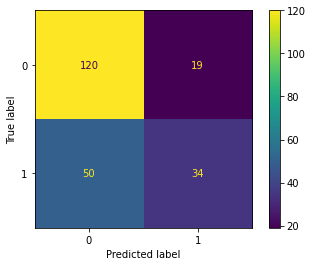

In [30]:
import matplotlib as plt 
plot_confusion_matrix(pipe,x_test,y_test)

In [31]:
from imblearn.over_sampling import RandomOverSampler
over= RandomOverSampler()
o_x , o_y = over.fit_resample(x,y)
o_y.value_counts()

Survived
0           549
1           549
dtype: int64

In [32]:
from imblearn.over_sampling import SMOTE
over= RandomOverSampler()
_x , o_y = over.fit_resample(x,y)
o_y.value_counts()

Survived
0           549
1           549
dtype: int64

In [33]:
from imblearn.pipeline import make_pipeline
s = SMOTE()
n_pipe = make_pipeline(trans,s,algorithm)
n_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('smote', SMOTE()),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=15))])

In [34]:
accuracy_score(pred,y_test)*100

69.05829596412556

In [35]:
from sklearn.linear_model import LogisticRegression as lr
algorithm_2 = lr(solver='liblinear')
pipe_2 = make_pipeline(trans,algorithm_2)
pipe_2

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [36]:
pipe_2.fit(x_train,y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('logisticregression', LogisticRegression(solver='liblinear'))])

In [37]:
pred_2 = pipe_2.predict(x_test)
pred_2

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0])

In [38]:
accuracy_score(pred_2,y_test)*100

82.0627802690583

In [39]:
from sklearn.model_selection import KFold, cross_val_score,StratifiedKFold
kf=StratifiedKFold(n_splits=4)
np.mean(cross_val_score(pipe,x,y,cv=kf,scoring='accuracy')*100)

/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:335: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:335: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:335: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:335: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the

73.29010624974751

In [40]:
from sklearn.svm import SVC
model1=SVC(kernel='linear')
pipe_1 = make_pipeline(trans,algorithm)
pipe_1
pipe_1.fit(x_train,y_train)
pred_1=pipe.predict(x_test)
accuracy_score(pred_1,y_test)*100

/opt/conda/lib/python3.7/site-packages/imblearn/pipeline.py:272: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  self._final_estimator.fit(Xt, yt, **fit_params_last_step)


69.05829596412556

In [41]:
from sklearn.ensemble import BaggingClassifier
model2=BaggingClassifier(base_estimator=SVC(3))
model2

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:70: FutureWarning: Pass C=3 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  FutureWarning)


BaggingClassifier(base_estimator=SVC(C=3))

In [42]:
y_test.shape

(223, 1)

In [43]:
pipe5=make_pipeline(trans,model2)
pipe5

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse=False),
                                                  []),
                                                 ('knnimputer',
                                                  KNNImputer(n_neighbors=45),
                                                  [1, 2, 6, 7, 8]),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(), []),
                                                 ('standardscaler',
                                                  StandardScaler(), [0, 4, 5]),
                                                 ('binarizer',
                                                  Binarizer(threshold=55),
                                                  [3])])),
                ('baggingclassifier',
                 BaggingClassifier(base_estimator=SVC(C=3)))])

In [44]:
pipe5.fit(x_train,y_train)
pred5=pipe5.predict(x_test)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


In [45]:
pred5.shape

(223,)

In [46]:
accuracy_score(pred5,y_test)*100

71.30044843049326

In [47]:
data1=pd.read_csv('/kaggle/input/titanic/test.csv')
data1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [48]:
data1['Sex'].replace( 'female', 0, inplace=True )
data1['Sex'].replace( 'male', 1, inplace=True )

In [49]:
data1.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [50]:
#data1.Age=data1.Age.fillna(0)
data1.Cabin=data1.Cabin.fillna(0)
data1.Fare=data1.Fare.fillna(0)

In [51]:
data1.isnull().sum()

PassengerId     0
Pclass          0
Name            0
Sex             0
Age            86
SibSp           0
Parch           0
Ticket          0
Fare            0
Cabin           0
Embarked        0
dtype: int64

In [52]:
#data1=data1[data1.Embarked!=0]
#data1=data1[data1[('Embarked')].map(data1['Embarked'].value_counts())>0]
#data1

In [53]:
#data1.loc[data1['Sex']=='male']=1
#data1.loc[data1['Sex']=='female']=0

In [54]:
data1['Embarked_s']=data1['Embarked'].replace('Q',0).replace('C',0).replace('S',1)
data1['Embarked_c']=data1['Embarked'].replace('S',0).replace('Q',0).replace('C',1)
data1['Embarked_q']=data1['Embarked'].replace('C',0).replace('S',0).replace('Q',1)

In [55]:
data1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Embarked_s,Embarked_c,Embarked_q
0,892,3,"Kelly, Mr. James",1,34.5,0,0,330911,7.8292,0,Q,0,0,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,363272,7.0000,0,S,1,0,0
2,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,240276,9.6875,0,Q,0,0,1
3,895,3,"Wirz, Mr. Albert",1,27.0,0,0,315154,8.6625,0,S,1,0,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,3101298,12.2875,0,S,1,0,0


In [56]:
x1 = data1.drop(columns = ['Ticket','Cabin','PassengerId','Name','Embarked'])
x1

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_s,Embarked_c,Embarked_q
0,3,1,34.5,0,0,7.8292,0,0,1
1,3,0,47.0,1,0,7.0000,1,0,0
2,2,1,62.0,0,0,9.6875,0,0,1
3,3,1,27.0,0,0,8.6625,1,0,0
4,3,0,22.0,1,1,12.2875,1,0,0
...,...,...,...,...,...,...,...,...,...
413,3,1,NaN,0,0,8.0500,1,0,0
414,1,0,39.0,0,0,108.9000,0,1,0
415,3,1,38.5,0,0,7.2500,1,0,0
416,3,1,NaN,0,0,8.0500,1,0,0


In [57]:
x1.isnull().sum()

Pclass         0
Sex            0
Age           86
SibSp          0
Parch          0
Fare           0
Embarked_s     0
Embarked_c     0
Embarked_q     0
dtype: int64

In [58]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,KBinsDiscretizer,Binarizer
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.compose import make_column_transformer
from sklearn import set_config
from sklearn.preprocessing import StandardScaler

trans = make_column_transformer((OneHotEncoder(sparse=False),nom_cols),
                                (KNNImputer(n_neighbors=45),null_cols),
                                (OrdinalEncoder(), ord_cols),(StandardScaler(),num_cols)
                                 ,(Binarizer(threshold=55),binarizer_cols),remainder= 'passthrough')
set_config(display= 'diagram')
trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder', OneHotEncoder(sparse=False),
                                 []),
                                ('knnimputer', KNNImputer(n_neighbors=45),
                                 [1, 2, 6, 7, 8]),
                                ('ordinalencoder', OrdinalEncoder(), []),
                                ('standardscaler', StandardScaler(), [0, 4, 5]),
                                ('binarizer', Binarizer(threshold=55), [3])])

In [59]:
pred123=pipe_x.predict(x1)
pred123

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [60]:
#survival_prediction=algorithm.predict(x1)
#survival_prediction

In [61]:
submit=pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [62]:
submit['Survived']=pred123
submit.to_csv('submission.csv', index=False)

In [63]:
submit.Survived.value_counts()

0    247
1    171
Name: Survived, dtype: int64